In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [6]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA‐Based Clustering

We now reduce our 12‐dimensional feature space down to 2 principal components (PCs), quantify how much variance they capture, and then run K-Means on this 2D projection.

## Variance Explained by Principal Components
- **PC1 + PC2 capture 99.5% of the total variance**  
  Nearly all of the dataset’s variability lives in these two dimensions, indicating a highly redundant feature space.
- **Cluster Separation**  
  In the left panel, KMeans cleanly divides the PC‐space into two dense groups with minimal overlap.
- **Label Alignment**  
  The right panel confirms that the unsupervised clusters correspond closely to red vs. white wines.

## Interpretation
- **Dimension Reduction Success**  
    Compressing 12 features down to 2 principal components retains almost all the distinguishing information.
- **Robust Unsupervised Grouping**  
    KMeans on PC1/PC2 achieves near‐perfect separation, matching the true wine types without using labels.
- **Practical Implications**  
    **Visualization:** 2D plots suffice for both exploratory analysis and presentation.  
    **Speed:** Downstream clustering or classification models can be trained much faster in this 2D space.  
    **Feature Engineering:** PCs themselves may serve as powerful predictors in supervised tasks.

PC1 explains 95.4% of variance
PC2 explains 4.1% of variance


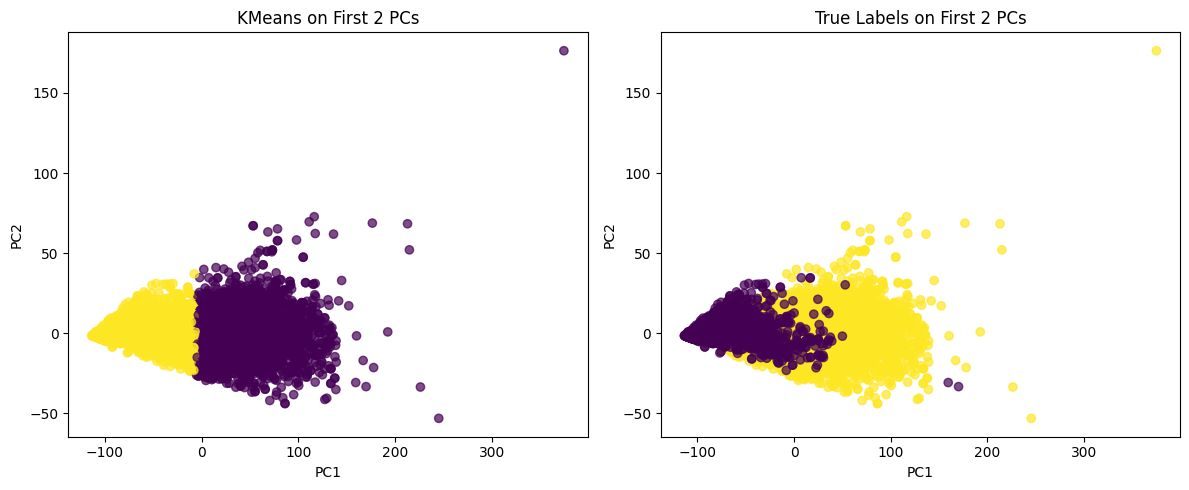

In [10]:
# 1. Fit PCA to the full feature matrix X
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# 2. Variance explained by the first two PCs
explained_var = pca.explained_variance_ratio_
print(f"PC1 explains {explained_var[0]*100:.1f}% of variance")
print(f"PC2 explains {explained_var[1]*100:.1f}% of variance")

# 3. Cluster in the 2D PC space
kmeans_pca = KMeans(n_clusters=2, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# 4. Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 4a. KMeans clusters in PC space
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.7)
ax[0].set_title("KMeans on First 2 PCs")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# 4b. True labels in PC space
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y.map({'red':0,'white':1}), cmap='viridis', alpha=0.7)
ax[1].set_title("True Labels on First 2 PCs")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()
